# Week 4 Day 2 Lab


### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [1]:
import numpy as np
import pandas as pd
data = np.random.randint(1, 101, 300)
df = pd.DataFrame(data, columns=["values"])
df.to_csv("random_data.csv", index = False)
df.head()

,values
0,2
1,1
2,83
3,63
4,52


### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

In [7]:
x = [100,201,303,405,503]
np.mean(x)

302.4

In [4]:
pd.read_csv("random_data.csv")

,values
0,2
1,1
2,83
3,63
4,52
...,...
295,20
296,22
297,5
298,23


In [5]:
def my_mean(x):
    return sum(x) / len(x)
def my_median(x):
    x = sorted(x)
    n = len(x)
    if n % 2 == 0:
        return (x[n//2-1] + x[n//2] / 2)
    else:
        return x[n//2]
def my_mode(x):
    counts ={}
    for value in x:
        counts[value] = counts.get(value, 0) +1
    max_count = max(counts.values())
    for key in counts:
        if counts[key] == max_count:
            return key
            

In [6]:
values = df["values"].tolist()
mean = my_mean(values)
median = my_median(values)
mode = my_mode(values)
print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

Mean: 50.03
Median: 73.5
Mode: 46


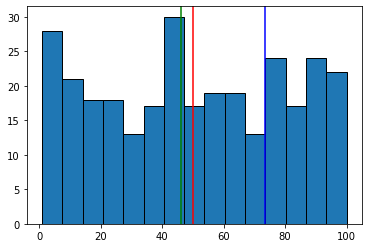

In [7]:
import matplotlib.pyplot as plt
plt.hist(values, bins=15, edgecolor="black")
plt.axvline(mean, color="red", label="Mean")
plt.axvline(median, color="blue", label="Median")
plt.axvline(mode, color="green", label="Mode")
plt.show()

The mean of my data seems to be about 50, where the true middle number is about 75, and the mode is below 50. This makes sense because even though the median is much higher the fact that we have higher numbers of values below 50 which brings our mean down. 

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

In [9]:
def mad(x):
    mean = my_mean(x)
    total = 0
    for value in x:
        total += abs(value - mean)
    return total / len(x)
def variance(x):
    mean = my_mean(x)
    total = 0
    for value in x:
        total += abs(value - mean) **2
    return total / len(x)
def standard_deviation(x):
    return variance(x) **0.5

In [10]:
mean = my_mean(values)
mad_value = mad(values)
var = variance(values)
std = standard_deviation(values)
print("Mean Absolute Deviation:", mad_value)
print("Variance:", var)
print("Standard Deviation:", std)

Mean Absolute Deviation: 25.677266666666657
Variance: 889.3224333333327
Standard Deviation: 29.821509575025416


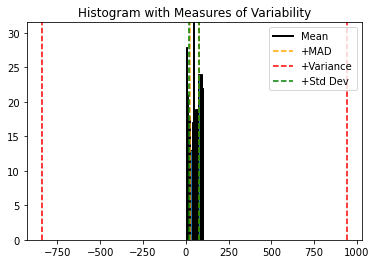

In [12]:
plt.hist(values, bins=15, edgecolor="black")
plt.axvline(mean, color="black", linewidth=2,label="Mean")
plt.axvline(mean + mad_value, color="orange", linestyle="--", label="+MAD")
plt.axvline(mean - mad_value, color="orange", linestyle="--")
plt.axvline(mean + var, color="red", linestyle="--", label="+Variance")
plt.axvline(mean - var, color="red", linestyle="--")
plt.axvline(mean + std, color="green", linestyle="--", label="+Std Dev")
plt.axvline(mean - std, color="green", linestyle="--")
plt.legend()
plt.title("Histogram with Measures of Variability")
plt.show()

Because the variance is squared the results for variance are vastly outside my data range. This makes the graph difficult to read.